<a href="https://colab.research.google.com/github/khushi-awasthi/Smart-Reservoir-Management-System/blob/main/Reservoir_LSTM_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow scikit-learn joblib


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
from google.colab import files
uploaded = files.upload()


TypeError: 'NoneType' object is not subscriptable

In [ ]:
df = pd.read_csv("reservoir_data.csv", parse_dates=["Date"], index_col="Date")
df.head()


,Reservoir_Level_ML,Inflow_ML,Outflow_ML,Rainfall_mm,Temperature_C,Water_Demand_ML
Date,,,,,,
2005-01-01,524.835708,50.000000,128.120691,0.387392,32.987105,92.180047
2005-01-02,493.086785,120.432704,96.881130,0.970985,28.372881,106.982503
2005-01-03,532.384427,128.727361,109.971263,0.487305,28.150332,102.949104
2005-01-04,576.151493,78.996269,95.648061,1.394685,21.936699,87.063603
2005-01-05,488.292331,80.554035,79.433068,3.076602,35.541848,92.115495


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
joblib.dump(scaler, 'scaler.pkl')  # Save the scaler

def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 30
X, y = create_sequences(scaled_data, SEQ_LEN)

# Split into train/test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]



In [ ]:
model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, X.shape[2])),
    Dense(X.shape[2])  # Multi-output for Level, Demand, Inflow
])
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)
model.save("lstm_model.keras")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0453 - val_loss: 0.0236
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0235 - val_loss: 0.0235
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0231 - val_loss: 0.0243
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0232 - val_loss: 0.0233
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0236 - val_loss: 0.0238
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0235 - val_loss: 0.0238
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0233 - val_loss: 0.0235
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0232 - val_loss: 0.0236
Epoch 9/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0231 - val_loss: 0.0235
Epoch 10/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0234 - val_loss: 0.0234
Epoch 11/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0230 - val_loss: 0.0235
Epoch 12/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
model = load_model("lstm_model.keras")

scaler = joblib.load("scaler.pkl")

# Use the last 30 days of data
last_seq = scaled_data[-SEQ_LEN:]
forecast = []

for _ in range(30):  # Predict 30 days
    pred = model.predict(last_seq.reshape(1, SEQ_LEN, X.shape[2]), verbose=0)[0]
    forecast.append(pred)
    last_seq = np.append(last_seq[1:], [pred], axis=0)

forecast = scaler.inverse_transform(forecast)

# Create date index
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30)
forecast_df = pd.DataFrame(forecast, columns=df.columns, index=future_dates)
forecast_df.head()


,Reservoir_Level_ML,Inflow_ML,Outflow_ML,Rainfall_mm,Temperature_C,Water_Demand_ML
2025-01-01,497.059946,100.429147,97.762724,5.396898,28.184103,91.395787
2025-01-02,497.408844,100.191116,96.654894,5.365026,28.167447,90.839216
2025-01-03,497.521992,100.283384,96.810743,5.312971,28.162110,90.818847
2025-01-04,497.428816,100.255203,96.799597,5.302204,28.142396,90.754329
2025-01-05,497.463538,100.239301,96.830901,5.294971,28.139444,90.718461


In [ ]:
print(df.columns.tolist())


NameError: name 'df' is not defined

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index[-60:], df["Reservoir_Level_ML"].values[-60:], label="Actual Reservoir Level")
plt.plot(forecast_df.index, forecast_df["Reservoir_Level_ML"], label="Forecasted Level", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Reservoir Level (ML)")
plt.title("30-Day Reservoir Level Forecast")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'plt' is not defined

In [ ]:
forecast_df = pd.DataFrame(forecast, columns=[
    'Reservoir_Level_ML',
    'Inflow_ML',
    'Outflow_ML',
    'Rainfall_mm',
    'Temperature_C',
    'Water_Demand_ML'
], index=future_dates)


NameError: name 'pd' is not defined

In [ ]:
forecast_df.to_csv("forecast_next_30_days.csv")
files.download("forecast_next_30_days.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import random

# Constants
POP_SIZE = 100
N_GENERATIONS = 200
MUTATION_RATE = 0.1
MAX_CAP = 1000  # Max reservoir capacity (in ML)
MIN_CAP = 200   # Minimum safe level (in ML)
RELEASE_MIN = 0
RELEASE_MAX = 100  # Max daily release

def fitness(release_schedule, inflow, demand, initial_level):
    level = initial_level
    penalty = 0

    for t in range(len(release_schedule)):
        inflow_t = inflow[t]
        demand_t = demand[t]
        release_t = release_schedule[t]

        level += inflow_t - release_t

        # Overflow penalty
        if level > MAX_CAP:
            penalty += (level - MAX_CAP)**2

        # Shortage penalty
        if level < MIN_CAP:
            penalty += (MIN_CAP - level)**2

        # Not meeting demand penalty
        if release_t < demand_t:
            penalty += (demand_t - release_t)**2

    return -penalty  # GA maximizes, so we return negative penalty

def create_individual(length):
    return [random.uniform(RELEASE_MIN, RELEASE_MAX) for _ in range(length)]

def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    return p1[:point] + p2[point:]

def mutate(individual):
    return [
        val + random.uniform(-5, 5) if random.random() < MUTATION_RATE else val
        for val in individual
    ]

def genetic_algorithm(inflow, demand, initial_level):
    population = [create_individual(len(inflow)) for _ in range(POP_SIZE)]

    for _ in range(N_GENERATIONS):
        scored = [(ind, fitness(ind, inflow, demand, initial_level)) for ind in population]
        scored.sort(key=lambda x: x[1], reverse=True)
        population = [ind for ind, _ in scored[:POP_SIZE//2]]  # Top 50%

        new_population = []
        while len(new_population) < POP_SIZE:
            p1, p2 = random.sample(population, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            new_population.append(child)

        population = new_population

    best = max(population, key=lambda ind: fitness(ind, inflow, demand, initial_level))
    return best


In [ ]:
# Get forecasted inflow and demand from your LSTM forecast
inflow = forecast_df["Inflow_ML"].values
demand = forecast_df["Water_Demand_ML"].values
initial_level = df["Reservoir_Level_ML"].iloc[-1]  # Last known level


In [ ]:
release_schedule = genetic_algorithm(inflow, demand, initial_level)

optimized_df = pd.DataFrame({
    "Date": forecast_df.index,
    "Forecasted Inflow (ML)": inflow,
    "Forecasted Demand (ML)": demand,
    "Optimized Release (ML)": release_schedule
}).set_index("Date")

optimized_df.head()


,Forecasted Inflow (ML),Forecasted Demand (ML),Optimized Release (ML)
Date,,,
2025-01-01,100.429147,91.395787,101.870468
2025-01-02,100.191116,90.839216,101.210906
2025-01-03,100.283384,90.818847,91.907770
2025-01-04,100.255203,90.754329,94.979704
2025-01-05,100.239301,90.718461,92.058454


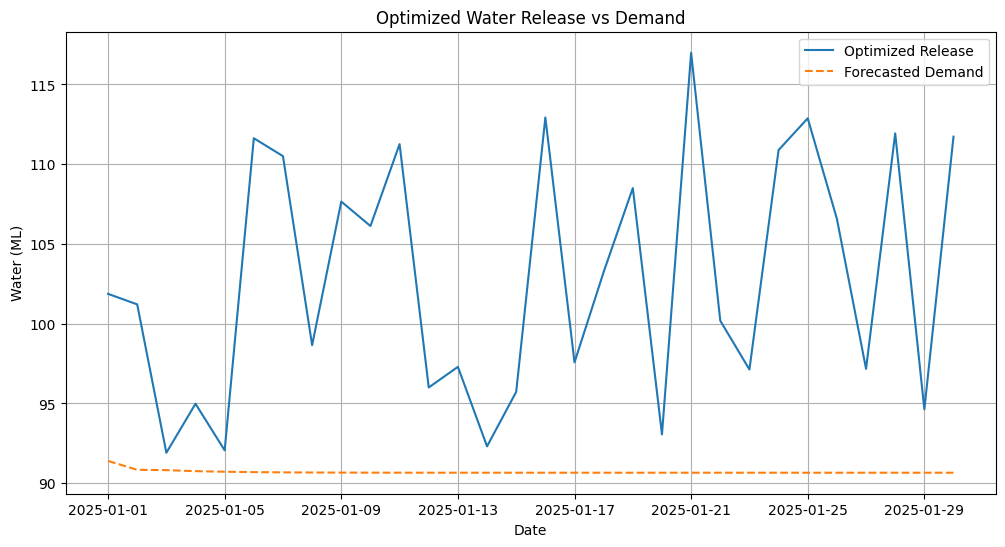

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(optimized_df.index, optimized_df["Optimized Release (ML)"], label="Optimized Release")
plt.plot(optimized_df.index, optimized_df["Forecasted Demand (ML)"], label="Forecasted Demand", linestyle="--")
plt.title("Optimized Water Release vs Demand")
plt.xlabel("Date")
plt.ylabel("Water (ML)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Merge the optimized release back into the forecast DataFrame
forecast_df["Optimized_Release_ML"] = optimized_df["Optimized Release (ML)"]


In [ ]:
# Concatenate historical and forecasted data
# Ensure both DataFrames have the same columns
df_combined = pd.concat([df, forecast_df])


In [ ]:
import os

# Create directory for Tableau exports
os.makedirs("data/tableau_exports", exist_ok=True)

# Export the combined data to CSV
df_combined.to_csv("data/tableau_exports/reservoir_forecast_optimized.csv")


In [ ]:
from google.colab import files

# Download the CSV from Colab to local system
files.download("data/tableau_exports/reservoir_forecast_optimized.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>